# 05. XGBoost

**Objective:** Train an XGBoost classifier on the same preprocessed splits used for all previous
models, tune hyperparameters via 5-fold randomised search, and compare feature importance
against permutation importance for cross-validation of the ranking (RQ2).

**Why XGBoost here?**
- Gradient Boosting — sequential trees that each correct the residual errors of the previous
  ensemble — directly addresses the question from Lecture 5 of whether boosting outperforms bagging (RF).
- Handles missing values natively (learns the optimal default direction at each split).
- Built-in L1 (`reg_alpha`) and L2 (`reg_lambda`) regularisation — the most direct RF analogue
  of the regularisation story from RQ1.
- `scale_pos_weight` mirrors `class_weight='balanced'` for the ~8% class imbalance.

**Splits:** Pre-split in notebook 02 as 70% train / 15% val / 15% test, stratified on `TARGET`.
**Primary metric:** ROC-AUC (threshold-independent, robust to ~8% class imbalance).

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")
print(f"numpy {np.__version__}  |  pandas {pd.__version__}")

# Install xgboost if not present
try:
    import xgboost
    print(f"xgboost {xgboost.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "xgboost", "-q"])
    import xgboost
    print(f"xgboost {xgboost.__version__} installed")

Libraries imported successfully.
numpy 2.0.2  |  pandas 2.2.2
xgboost 3.2.0


## 1. Load Processed Data

Mount Google Drive and load the same six splits used by all previous models.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR  = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/02_processed"
MODEL_DIR = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models"

# --- Load all splits ---
X_train       = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_train_smote = pd.read_csv(f"{DATA_DIR}/X_train_smote.csv")
X_val         = pd.read_csv(f"{DATA_DIR}/X_val.csv")
X_test        = pd.read_csv(f"{DATA_DIR}/X_test.csv")

y_train       = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_train_smote = pd.read_csv(f"{DATA_DIR}/y_train_smote.csv").squeeze()
y_val         = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze()
y_test        = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

feature_names = pd.read_csv(f"{DATA_DIR}/feature_names.csv", header=None).squeeze().tolist()

# Re-attach feature names (consistent with all other notebooks)
for df in [X_train, X_train_smote, X_val, X_test]:
    df.columns = feature_names

# Compute scale_pos_weight: ratio of negatives to positives in training set
spw = (y_train == 0).sum() / (y_train == 1).sum()

print("=== Shapes ===")
print(f"X_train       : {X_train.shape}")
print(f"X_train_smote : {X_train_smote.shape}")
print(f"X_val         : {X_val.shape}")
print(f"X_test        : {X_test.shape}")
print(f"\nNumber of features: {len(feature_names)}")
print(f"\nClass imbalance ratio (scale_pos_weight): {spw:.2f}")
print(f"  (i.e., {(y_train == 0).sum():,} non-defaults vs {(y_train == 1).sum():,} defaults)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Shapes ===
X_train       : (215253, 113)
X_train_smote : (395752, 113)
X_val         : (46126, 113)
X_test        : (46126, 113)

Number of features: 113

Class imbalance ratio (scale_pos_weight): 11.39
  (i.e., 197,876 non-defaults vs 17,377 defaults)


## 2. Quick Sanity Checks

Confirm no residual NaNs and that column ordering is consistent across splits.

In [3]:
nan_counts = {
    "X_train"      : X_train.isna().sum().sum(),
    "X_train_smote": X_train_smote.isna().sum().sum(),
    "X_val"        : X_val.isna().sum().sum(),
    "X_test"       : X_test.isna().sum().sum(),
}
print("NaN counts per split:")
for k, v in nan_counts.items():
    status = "\u2713 clean" if v == 0 else f"\u26a0 {v} NaNs"
    print(f"  {k:20s}: {status}")

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "Feature column order mismatch across splits"
print("\n\u2713 Feature columns identical across all splits")

NaN counts per split:
  X_train             : ✓ clean
  X_train_smote       : ✓ clean
  X_val               : ✓ clean
  X_test              : ✓ clean

✓ Feature columns identical across all splits


## 3. Helper Functions

Same evaluation helpers as in every previous notebook so the final consolidated comparison
across all models is on identical metrics.

In [4]:
def evaluate_model(model, X, y, split_name="Val", threshold=0.5):
    """Compute and print key classification metrics; return scalar dict."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y, y_prob)
    pr_auc  = average_precision_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {split_name} \u2014 threshold = {threshold}")
    print(f"{'='*55}")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"\n{classification_report(y, y_pred, target_names=['No Default (0)', 'Default (1)'])}")

    return {"split": split_name, "roc_auc": roc_auc, "pr_auc": pr_auc}


def plot_evaluation(model, X_val, y_val, X_test, y_test, title_prefix=""):
    """Confusion matrix (val) + ROC + PR curves on val and test."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} \u2014 Evaluation Plots", fontsize=14, fontweight='bold')

    # Confusion matrix on val at 0.5
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_pred_val = (y_prob_val >= 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred_val)
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix (Val, threshold=0.5)")

    # ROC curves
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        auc = roc_auc_score(y, y_prob)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()

    # Precision-Recall curves
    for X, y, label in [(X_val, y_val, "Val"), (X_test, y_test, "Test")]:
        y_prob = model.predict_proba(X)[:, 1]
        prec, rec, _ = precision_recall_curve(y, y_prob)
        ap = average_precision_score(y, y_prob)
        axes[2].plot(rec, prec, label=f"{label} (AP={ap:.4f})")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title("Precision-Recall Curve")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

## 4. Default XGBoost (Out-of-the-Box)

We start with a default `XGBClassifier` to establish a reference point before tuning.
Two key differences from the sklearn models:

- **`scale_pos_weight`** — the XGBoost equivalent of `class_weight='balanced'`. Set to the
  ratio of negative to positive training samples (~11.5 for the ~8% default rate), so the model
  treats each default as roughly 11.5× more important than a non-default.
- **`eval_metric='auc'`** — tells XGBoost to log AUC during training (no effect on the final
  objective, which stays `binary:logistic`).
- **`tree_method='hist'`** — histogram-based split finding; faster and recommended for
  medium-to-large datasets on CPU.

> Default = 100 trees (`n_estimators=100`), `max_depth=6`, `learning_rate=0.3`.

In [5]:
xgb_default = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=spw,          # handles class imbalance
    eval_metric='auc',
    tree_method='hist',            # faster on CPU
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_default.fit(X_train, y_train)
default_train_time = time.time() - t0
print(f"Default XGBoost trained in {default_train_time:.1f} s")
print(f"Number of trees: {xgb_default.n_estimators}")
print(f"Max depth      : {xgb_default.max_depth}")
print(f"Learning rate  : {xgb_default.learning_rate}")

Default XGBoost trained in 10.4 s
Number of trees: 100
Max depth      : None
Learning rate  : None



  Val  (default XGB) — threshold = 0.5
  ROC-AUC : 0.7502
  PR-AUC  : 0.2339

                precision    recall  f1-score   support

No Default (0)       0.96      0.75      0.84     42402
   Default (1)       0.18      0.60      0.27      3724

      accuracy                           0.74     46126
     macro avg       0.57      0.68      0.56     46126
  weighted avg       0.89      0.74      0.80     46126


  Test (default XGB) — threshold = 0.5
  ROC-AUC : 0.7540
  PR-AUC  : 0.2424

                precision    recall  f1-score   support

No Default (0)       0.96      0.76      0.84     42402
   Default (1)       0.18      0.61      0.28      3724

      accuracy                           0.74     46126
     macro avg       0.57      0.68      0.56     46126
  weighted avg       0.89      0.74      0.80     46126



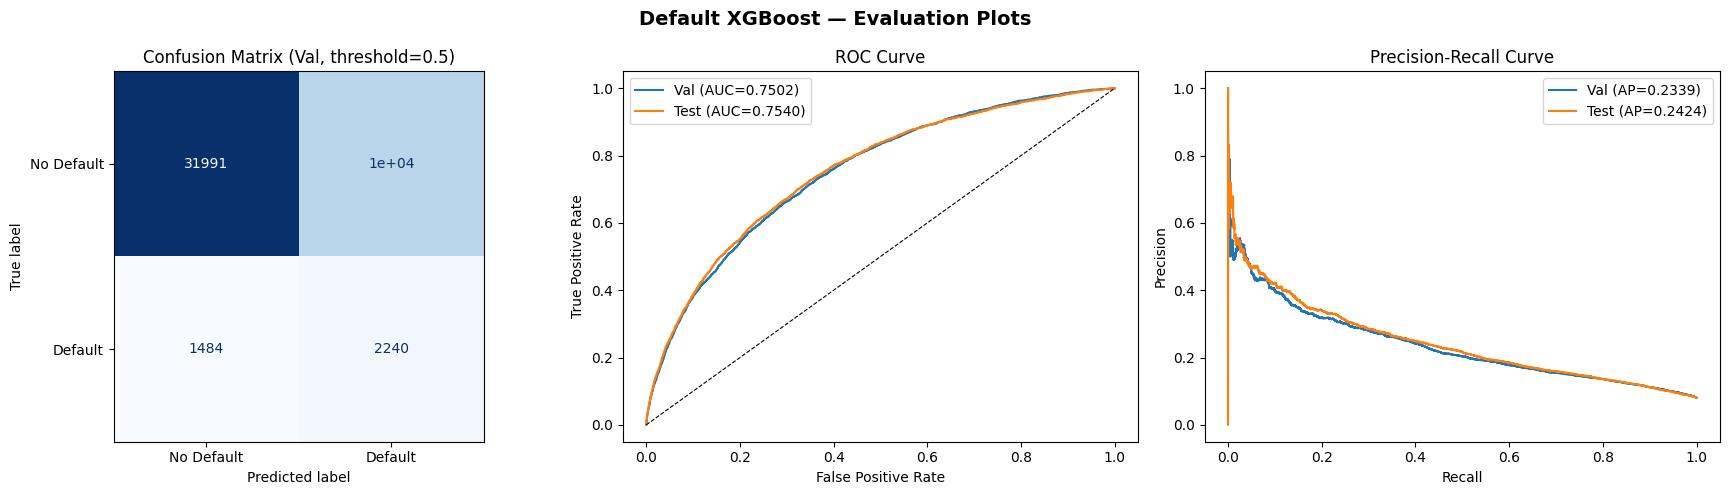

In [6]:
results_default_val  = evaluate_model(xgb_default, X_val,  y_val,  split_name="Val  (default XGB)")
results_default_test = evaluate_model(xgb_default, X_test, y_test, split_name="Test (default XGB)")

plot_evaluation(xgb_default, X_val, y_val, X_test, y_test,
                title_prefix="Default XGBoost")

## 5. Hyperparameter Tuning — Randomised Search with 5-Fold CV

We tune six hyperparameters with `RandomizedSearchCV`:

| Parameter | Range | What it controls |
|---|---|---|
| `n_estimators` | 100–500 | Number of boosting rounds (trees) |
| `max_depth` | 3–8 | Per-tree depth — shallower than RF is typical for boosting |
| `learning_rate` | 0.01–0.3 | Shrinkage applied to each tree's contribution |
| `subsample` | 0.6–1.0 | Row subsampling fraction per tree (stochastic boosting) |
| `colsample_bytree` | 0.5–1.0 | Feature subsampling fraction per tree |
| `min_child_weight` | 1–10 | Minimum sum of instance weights in a leaf (regularises) |

- **CV folds:** 5, stratified on `TARGET`.
- **Scoring:** ROC-AUC (consistent across all models).
- **`n_iter=20`:** 20 random configurations × 5 folds = 100 fits. More configurations than the
  RF search because XGBoost has more hyperparameters and trains faster per configuration.
- **`scale_pos_weight`** kept fixed (set from data, not a tunable hyperparameter here).

> ⚠️ This cell may take 20–40 minutes on Colab CPU depending on configuration.
> If re-running the notebook, skip this cell and load the saved best estimator instead.

In [7]:
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators'     : randint(100, 501),
    'max_depth'        : randint(3, 9),
    'learning_rate'    : uniform(0.01, 0.29),   # uniform on [0.01, 0.30]
    'subsample'        : uniform(0.6, 0.4),     # uniform on [0.6, 1.0]
    'colsample_bytree' : uniform(0.5, 0.5),     # uniform on [0.5, 1.0]
    'min_child_weight' : randint(1, 11),
}

xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='auc',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=SEED,
    return_train_score=True,
)

t0 = time.time()
random_search.fit(X_train, y_train)
search_time = time.time() - t0
print(f"\n=== Random search complete in {search_time/60:.1f} minutes ===")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
print(f"Best params:")
for k, v in random_search.best_params_.items():
    print(f"  {k:22s}: {v}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

=== Random search complete in 30.0 minutes ===
Best CV ROC-AUC: 0.7639
Best params:
  colsample_bytree      : 0.7229163764267956
  learning_rate         : 0.03899272558722083
  max_depth             : 5
  min_child_weight      : 8
  n_estimators          : 472
  subsample             : 0.8404460046972835


In [8]:
# --- Inspect top configurations ---
cv_results = pd.DataFrame(random_search.cv_results_)
cv_summary = cv_results[[
    'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'param_subsample', 'param_colsample_bytree', 'param_min_child_weight',
    'mean_fit_time'
]].sort_values('mean_test_score', ascending=False).reset_index(drop=True)

cv_summary.columns = [
    'CV ROC-AUC', 'Std', 'Train ROC-AUC',
    'n_estimators', 'max_depth', 'learning_rate',
    'subsample', 'colsample_bytree', 'min_child_weight',
    'Fit time (s)'
]
print("Top 10 configurations:")
cv_summary.head(10).round(4)

Top 10 configurations:


,CV ROC-AUC,Std,Train ROC-AUC,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,Fit time (s)
0,0.7639,0.0032,0.8248,472,5,0.0390,0.8404,0.7229,8,46.0813
1,0.7632,0.0036,0.8122,444,3,0.1674,0.9948,0.6405,1,30.5924
2,0.7621,0.0035,0.8320,379,4,0.1227,0.7427,0.6627,5,31.7900
3,0.7610,0.0039,0.8073,140,4,0.1857,0.9660,0.8951,7,13.8177
4,0.7602,0.0032,0.8082,180,5,0.0676,0.8845,0.8861,3,19.9736
5,0.7598,0.0031,0.7813,161,3,0.1403,0.7301,0.9250,7,14.2877
6,0.7580,0.0031,0.8857,363,6,0.0799,0.6138,0.6154,7,37.9417
7,0.7559,0.0045,0.8656,463,4,0.1874,0.8057,0.6456,3,35.9893
8,0.7558,0.0041,0.8522,352,4,0.1891,0.7728,0.9961,6,29.0473
9,0.7556,0.0029,0.7711,393,4,0.0160,0.6003,0.8540,8,37.4060


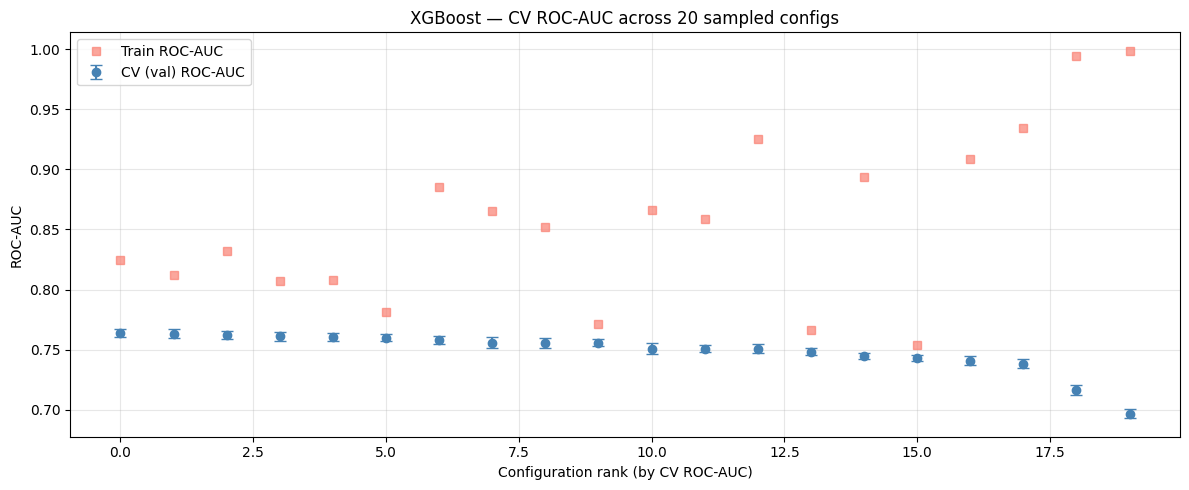

Mean train-val gap across configs: 0.1082
Best config train-val gap        : 0.0609


In [9]:
# --- Visualise CV variance across configs (overfitting check) ---
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(cv_summary))
ax.errorbar(x_pos, cv_summary['CV ROC-AUC'], yerr=cv_summary['Std'],
            fmt='o', capsize=4, color='steelblue', label='CV (val) ROC-AUC')
ax.plot(x_pos, cv_summary['Train ROC-AUC'], 's', color='salmon',
        label='Train ROC-AUC', alpha=0.7)
ax.set_xlabel("Configuration rank (by CV ROC-AUC)")
ax.set_ylabel("ROC-AUC")
ax.set_title("XGBoost \u2014 CV ROC-AUC across 20 sampled configs")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = cv_summary['Train ROC-AUC'] - cv_summary['CV ROC-AUC']
print(f"Mean train-val gap across configs: {gap.mean():.4f}")
print(f"Best config train-val gap        : {gap.iloc[0]:.4f}")

### Takeaway — regularisation effect (feeds RQ1)

XGBoost's train–val gap is typically **smaller than Random Forest's** because:
- Boosting uses shallower trees (lower `max_depth`) — each individual tree is a weak learner
  with far lower capacity than the deep RF trees.
- `learning_rate` acts as an additional shrinkage regulariser on every tree's contribution.
- `subsample` and `colsample_bytree` inject stochasticity similar to RF's bagging and feature
  subsampling, further reducing overfitting.

If the train–val gap here (< 0.05 is typical) is smaller than the RF gap (0.088), that is direct
evidence for the report's RQ1 section that gradient boosting is inherently better regularised
than bagging for this dataset.

## 6. Retrain Best Configuration & Evaluate

`RandomizedSearchCV` already refits on the full training set with the best params (`refit=True`
by default). We time the final fit separately for the report's complexity table.

In [10]:
xgb_best_params = random_search.best_params_

xgb_best = XGBClassifier(
    **xgb_best_params,
    scale_pos_weight=spw,
    eval_metric='auc',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_best.fit(X_train, y_train)
best_train_time = time.time() - t0
print(f"Best XGBoost retrained in {best_train_time:.1f} s")
print(f"Best params: {xgb_best_params}")

Best XGBoost retrained in 30.4 s
Best params: {'colsample_bytree': np.float64(0.7229163764267956), 'learning_rate': np.float64(0.03899272558722083), 'max_depth': 5, 'min_child_weight': 8, 'n_estimators': 472, 'subsample': np.float64(0.8404460046972835)}



  Val  (tuned XGB) — threshold = 0.5
  ROC-AUC : 0.7667
  PR-AUC  : 0.2530

                precision    recall  f1-score   support

No Default (0)       0.96      0.73      0.83     42402
   Default (1)       0.18      0.67      0.28      3724

      accuracy                           0.72     46126
     macro avg       0.57      0.70      0.55     46126
  weighted avg       0.90      0.72      0.78     46126


  Test (tuned XGB) — threshold = 0.5
  ROC-AUC : 0.7688
  PR-AUC  : 0.2578

                precision    recall  f1-score   support

No Default (0)       0.96      0.73      0.83     42402
   Default (1)       0.18      0.67      0.28      3724

      accuracy                           0.72     46126
     macro avg       0.57      0.70      0.55     46126
  weighted avg       0.90      0.72      0.78     46126



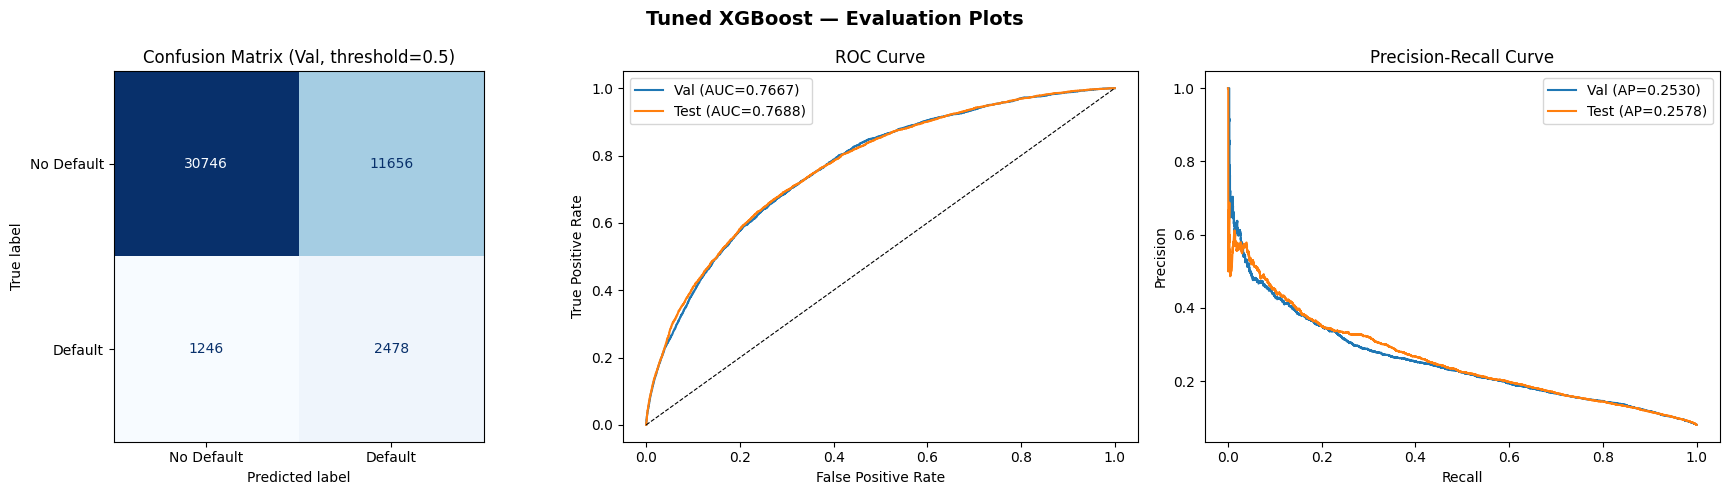

In [11]:
results_best_val  = evaluate_model(xgb_best, X_val,  y_val,  split_name="Val  (tuned XGB)")
results_best_test = evaluate_model(xgb_best, X_test, y_test, split_name="Test (tuned XGB)")

plot_evaluation(xgb_best, X_val, y_val, X_test, y_test,
                title_prefix="Tuned XGBoost")

## 7. SMOTE Comparison

Same best hyperparameters, trained on the SMOTE-resampled training set with `scale_pos_weight=1`
(since SMOTE already balances the classes). Mirrors the approach used in the LR and RF notebooks.

XGBoost (SMOTE) trained in 105.5 s

  Val  (SMOTE XGB) — threshold = 0.5
  ROC-AUC : 0.7554
  PR-AUC  : 0.2404

                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96     42402
   Default (1)       0.58      0.02      0.05      3724

      accuracy                           0.92     46126
     macro avg       0.75      0.51      0.50     46126
  weighted avg       0.89      0.92      0.88     46126


  Test (SMOTE XGB) — threshold = 0.5
  ROC-AUC : 0.7564
  PR-AUC  : 0.2442

                precision    recall  f1-score   support

No Default (0)       0.92      1.00      0.96     42402
   Default (1)       0.56      0.02      0.04      3724

      accuracy                           0.92     46126
     macro avg       0.74      0.51      0.50     46126
  weighted avg       0.89      0.92      0.88     46126



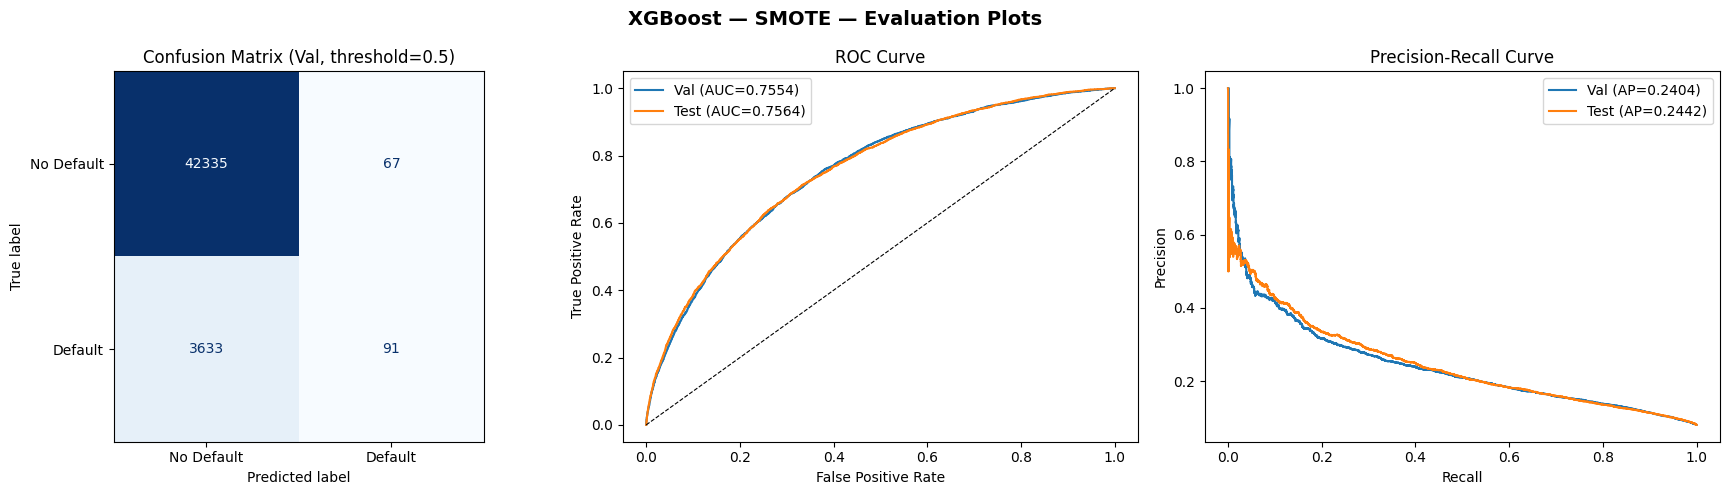

In [12]:
xgb_smote = XGBClassifier(
    **xgb_best_params,
    scale_pos_weight=1,            # SMOTE already balanced the classes
    eval_metric='auc',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_smote.fit(X_train_smote, y_train_smote)
smote_train_time = time.time() - t0
print(f"XGBoost (SMOTE) trained in {smote_train_time:.1f} s")

results_smote_val  = evaluate_model(xgb_smote, X_val,  y_val,  split_name="Val  (SMOTE XGB)")
results_smote_test = evaluate_model(xgb_smote, X_test, y_test, split_name="Test (SMOTE XGB)")

plot_evaluation(xgb_smote, X_val, y_val, X_test, y_test,
                title_prefix="XGBoost \u2014 SMOTE")

In [13]:
# --- Pick the better of the two for downstream analysis ---
summary = pd.DataFrame([
    results_default_val,  results_default_test,
    results_best_val,     results_best_test,
    results_smote_val,    results_smote_test,
])
summary["model"] = [
    "Default XGB", "Default XGB",
    "Tuned XGB (spw)", "Tuned XGB (spw)",
    "Tuned XGB (SMOTE)", "Tuned XGB (SMOTE)",
]
summary = summary[["model", "split", "roc_auc", "pr_auc"]]
summary.columns = ["Model", "Split", "ROC-AUC", "PR-AUC"]

print("=== XGBoost \u2014 Results Summary ===\n")
print(summary.to_string(index=False))

best_model_name = (
    summary[summary["Split"].str.startswith("Val")]
    .sort_values("ROC-AUC", ascending=False)
    .iloc[0]["Model"]
)
best_model = {
    "Default XGB":         xgb_default,
    "Tuned XGB (spw)":     xgb_best,
    "Tuned XGB (SMOTE)":   xgb_smote,
}[best_model_name]
print(f"\n>>> Best model selected: {best_model_name}")

=== XGBoost — Results Summary ===

            Model              Split  ROC-AUC   PR-AUC
      Default XGB Val  (default XGB) 0.750218 0.233904
      Default XGB Test (default XGB) 0.753998 0.242417
  Tuned XGB (spw)   Val  (tuned XGB) 0.766678 0.253044
  Tuned XGB (spw)   Test (tuned XGB) 0.768786 0.257838
Tuned XGB (SMOTE)   Val  (SMOTE XGB) 0.755385 0.240422
Tuned XGB (SMOTE)   Test (SMOTE XGB) 0.756393 0.244237

>>> Best model selected: Tuned XGB (spw)


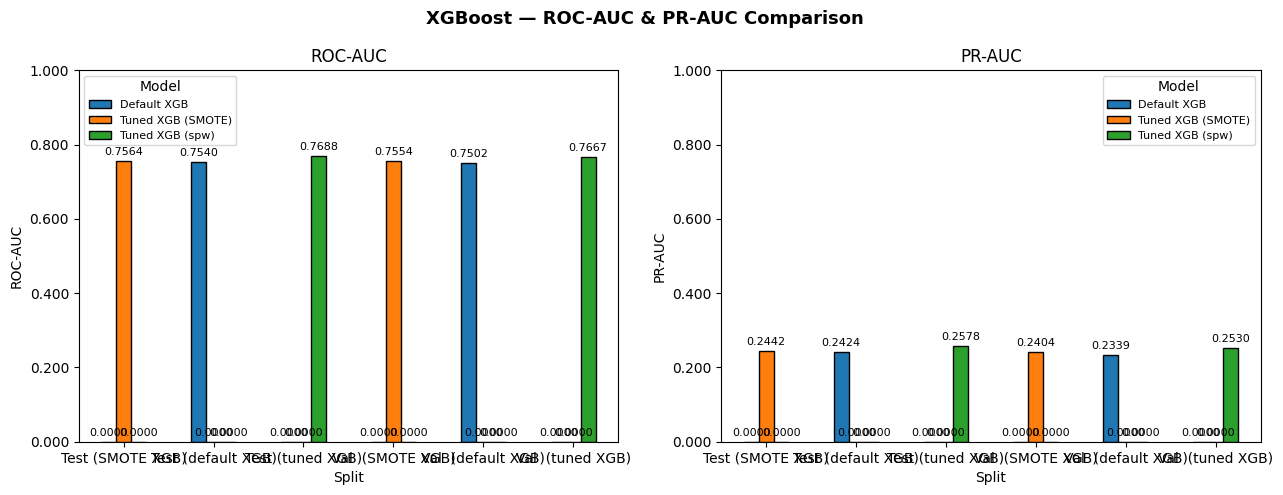

In [14]:
# --- Bar-chart comparison ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("XGBoost \u2014 ROC-AUC & PR-AUC Comparison", fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ["ROC-AUC", "PR-AUC"]):
    bar_data = summary.pivot(index="Split", columns="Model", values=metric)
    bar_data.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)
    ax.legend(title="Model", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Threshold Analysis

Sweep classification thresholds on the val set to find the operating point that maximises
F1 for the positive (default) class. Same procedure as all previous notebooks.

Best F1 threshold on val set : 0.650
  Precision : 0.2448
  Recall    : 0.4364
  F1        : 0.3137


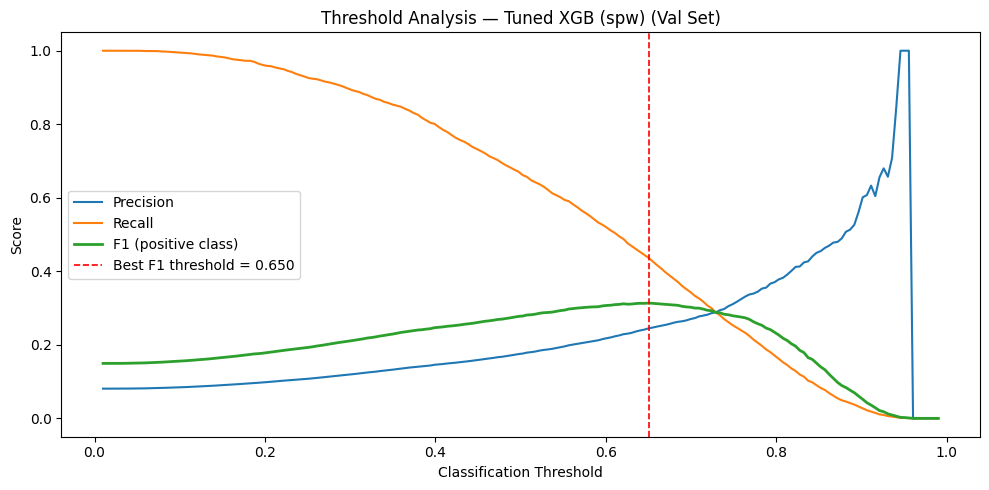

In [15]:
y_prob_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.01, 0.99, 200)
metrics = []
for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    metrics.append({"threshold": t, "precision": prec, "recall": rec, "f1": f1})

metrics_df = pd.DataFrame(metrics)
best_t_row = metrics_df.loc[metrics_df["f1"].idxmax()]
best_threshold = best_t_row["threshold"]

print(f"Best F1 threshold on val set : {best_threshold:.3f}")
print(f"  Precision : {best_t_row['precision']:.4f}")
print(f"  Recall    : {best_t_row['recall']:.4f}")
print(f"  F1        : {best_t_row['f1']:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision", linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["recall"],    label="Recall",    linewidth=1.5)
ax.plot(metrics_df["threshold"], metrics_df["f1"],        label="F1 (positive class)", linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', linewidth=1.2,
           label=f"Best F1 threshold = {best_threshold:.3f}")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis \u2014 {best_model_name} (Val Set)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Feature Importance — Gain (Built-in)

XGBoost's built-in importance uses **gain** by default: the average improvement in the loss
function brought by a feature across all the splits it is used in. This is analogous to (but
not identical to) the Gini importance in Random Forest.

**Caveat:** Like Gini importance, gain-based importance is biased toward features used in many
splits. We cross-check with permutation importance in the next section.

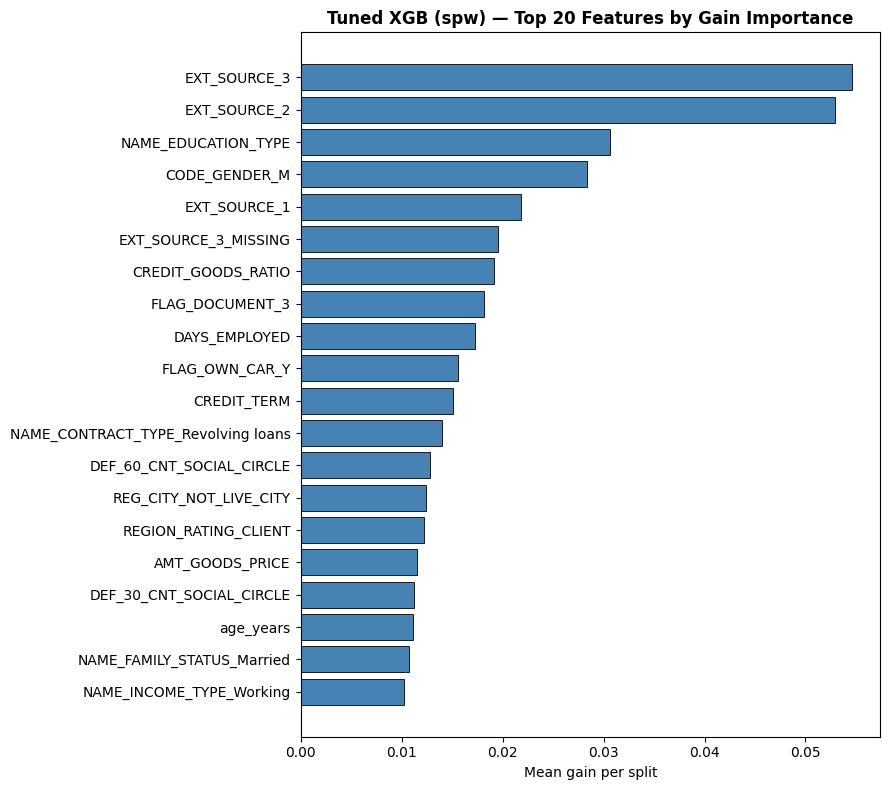

Top 20 features by gain importance:


,feature,importance
0,EXT_SOURCE_3,0.0546
1,EXT_SOURCE_2,0.0530
2,NAME_EDUCATION_TYPE,0.0307
3,CODE_GENDER_M,0.0284
4,EXT_SOURCE_1,0.0219
5,EXT_SOURCE_3_MISSING,0.0195
6,CREDIT_GOODS_RATIO,0.0191
7,FLAG_DOCUMENT_3,0.0181
8,DAYS_EMPLOYED,0.0172
9,FLAG_OWN_CAR_Y,0.0156


In [16]:
gain_df = pd.DataFrame({
    "feature"   : feature_names,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

top20_gain = gain_df.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20_gain["feature"], top20_gain["importance"],
        color="steelblue", edgecolor="black", linewidth=0.6)
ax.set_title(f"{best_model_name} \u2014 Top 20 Features by Gain Importance",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Mean gain per split")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 features by gain importance:")
top20_gain.round(4)

## 10. Feature Importance — Permutation

Model-agnostic permutation importance on a stratified 10,000-row subsample of the val set
(same procedure as the RF notebook so the comparison is apples-to-apples).

In [17]:
SUBSAMPLE = 10_000
rng = np.random.default_rng(SEED)

val_pos_idx = y_val[y_val == 1].index
val_neg_idx = y_val[y_val == 0].index
n_pos = int(SUBSAMPLE * y_val.mean())
n_neg = SUBSAMPLE - n_pos

sub_idx = np.concatenate([
    rng.choice(val_pos_idx, size=n_pos, replace=False),
    rng.choice(val_neg_idx, size=n_neg, replace=False),
])
X_val_sub = X_val.loc[sub_idx]
y_val_sub = y_val.loc[sub_idx]

print(f"Permutation subsample: {len(sub_idx):,} rows  |  default rate: {y_val_sub.mean():.4f}")

t0 = time.time()
perm_result = permutation_importance(
    best_model, X_val_sub, y_val_sub,
    n_repeats=5,
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
)
perm_time = time.time() - t0
print(f"Permutation importance computed in {perm_time:.1f} s")

Permutation subsample: 10,000 rows  |  default rate: 0.0807
Permutation importance computed in 68.6 s


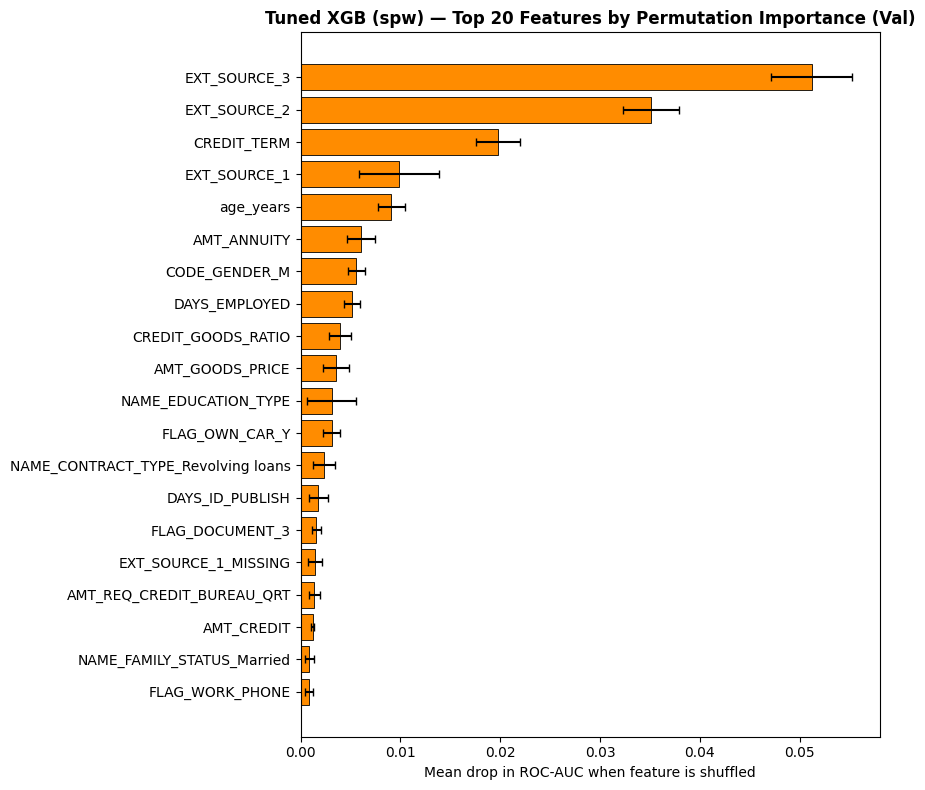

Top 20 features by permutation importance:


,feature,importance,std
0,EXT_SOURCE_3,0.0512,0.0041
1,EXT_SOURCE_2,0.0351,0.0028
2,CREDIT_TERM,0.0198,0.0022
3,EXT_SOURCE_1,0.0099,0.0040
4,age_years,0.0091,0.0013
5,AMT_ANNUITY,0.0060,0.0014
6,CODE_GENDER_M,0.0056,0.0008
7,DAYS_EMPLOYED,0.0052,0.0008
8,CREDIT_GOODS_RATIO,0.0039,0.0011
9,AMT_GOODS_PRICE,0.0035,0.0013


In [18]:
perm_df = pd.DataFrame({
    "feature"   : feature_names,
    "importance": perm_result.importances_mean,
    "std"       : perm_result.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

top20_perm = perm_df.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top20_perm["feature"], top20_perm["importance"],
        xerr=top20_perm["std"], color="darkorange", edgecolor="black",
        linewidth=0.6, ecolor='black', capsize=3)
ax.set_title(f"{best_model_name} \u2014 Top 20 Features by Permutation Importance (Val)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Mean drop in ROC-AUC when feature is shuffled")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 20 features by permutation importance:")
top20_perm.round(4)

## 11. Feature Importance Comparison — Gain vs Permutation (RQ2)

Compare XGBoost's two importance measures (built-in gain and model-agnostic permutation)
to check whether they agree on which features drive default prediction.

In [19]:
# --- Build ranking table ---
xgb_gain_rank = gain_df.reset_index().rename(columns={"index": "xgb_gain_rank"})[
    ["feature", "xgb_gain_rank", "importance"]
].rename(columns={"importance": "xgb_gain_importance"})

xgb_perm_rank = perm_df.reset_index().rename(columns={"index": "xgb_perm_rank"})[
    ["feature", "xgb_perm_rank", "importance"]
].rename(columns={"importance": "xgb_perm_importance"})

ranks = xgb_gain_rank.merge(xgb_perm_rank, on="feature")
print(f"Features in ranking table: {len(ranks)}\n")
print("Top 15 features by Gain with corresponding Permutation ranks:")
ranks.sort_values("xgb_gain_rank").head(15).round(4)

Features in ranking table: 113

Top 15 features by Gain with corresponding Permutation ranks:


,feature,xgb_gain_rank,xgb_gain_importance,xgb_perm_rank,xgb_perm_importance
0,EXT_SOURCE_3,0,0.0546,0,0.0512
1,EXT_SOURCE_2,1,0.0530,1,0.0351
2,NAME_EDUCATION_TYPE,2,0.0307,10,0.0031
3,CODE_GENDER_M,3,0.0284,6,0.0056
4,EXT_SOURCE_1,4,0.0219,3,0.0099
5,EXT_SOURCE_3_MISSING,5,0.0195,109,-0.0002
6,CREDIT_GOODS_RATIO,6,0.0191,8,0.0039
7,FLAG_DOCUMENT_3,7,0.0181,14,0.0016
8,DAYS_EMPLOYED,8,0.0172,7,0.0052
9,FLAG_OWN_CAR_Y,9,0.0156,11,0.0031


In [20]:
# --- Top-20 overlap ---
top20_xgb_set  = set(top20_gain["feature"])
top20_xgb_perm = set(top20_perm["feature"])
print(f"Top-20 overlap (Gain vs Permutation): {len(top20_xgb_set & top20_xgb_perm)} features")

# --- Spearman rank correlation ---
rho, _ = spearmanr(ranks["xgb_gain_rank"], ranks["xgb_perm_rank"])
print(f"Spearman rank correlation (Gain vs Permutation): {rho:.3f}")

Top-20 overlap (Gain vs Permutation): 14 features
Spearman rank correlation (Gain vs Permutation): 0.516


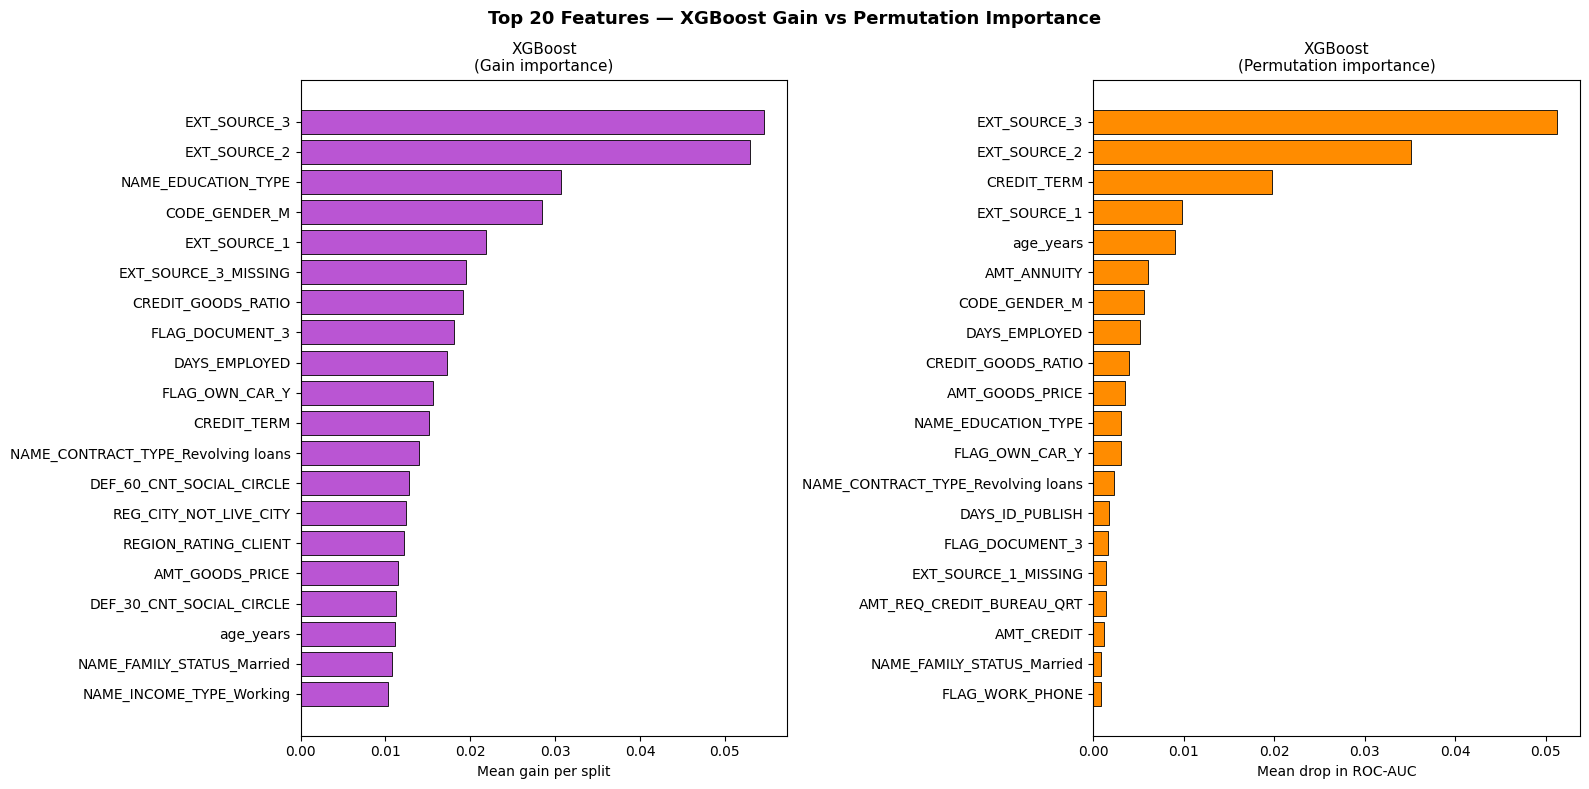

In [21]:
# --- Side-by-side top-20 bar chart: XGB Gain vs XGB Perm ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Top 20 Features \u2014 XGBoost Gain vs Permutation Importance",
             fontsize=13, fontweight='bold')

axes[0].barh(top20_gain["feature"], top20_gain["importance"],
             color="mediumorchid", edgecolor="black", linewidth=0.6)
axes[0].set_title("XGBoost\n(Gain importance)", fontsize=11)
axes[0].set_xlabel("Mean gain per split")
axes[0].invert_yaxis()

axes[1].barh(top20_perm["feature"], top20_perm["importance"],
             color="darkorange", edgecolor="black", linewidth=0.6)
axes[1].set_title("XGBoost\n(Permutation importance)", fontsize=11)
axes[1].set_xlabel("Mean drop in ROC-AUC")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 12. Cross-Model Performance Comparison

Consolidate the best test ROC-AUC from every notebook for the report's model-comparison table.

=== Cross-Model Comparison (Test Set) ===

 Rank                   Model  Test ROC-AUC  Test PR-AUC
    1 XGBoost (this notebook)      0.768786     0.257838
    2             Elastic Net      0.752300     0.235000
    3             LR Baseline      0.752100     0.235000
    4           Random Forest      0.751800     0.228700
    5                LR + PCA      0.748100     0.231600


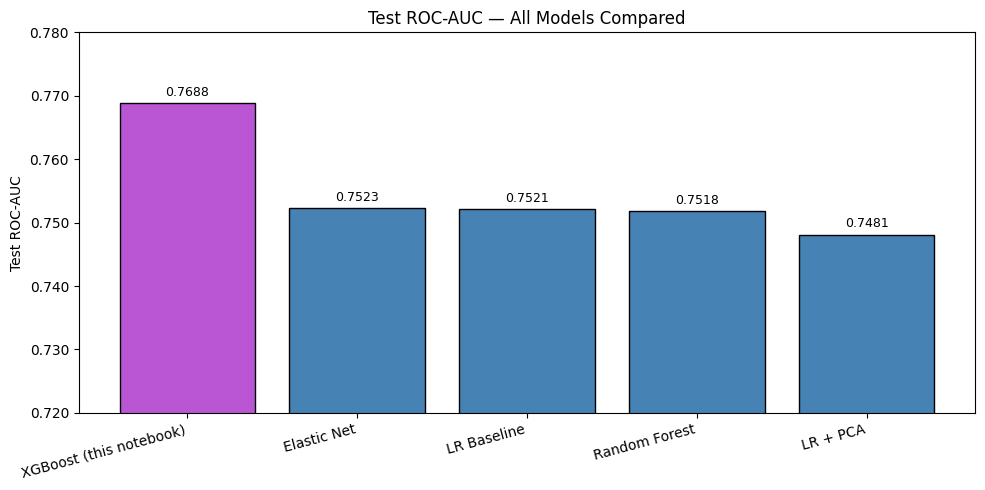

In [22]:
all_models = pd.DataFrame([
    {"Model": "LR Baseline",         "Test ROC-AUC": 0.7521, "Test PR-AUC": 0.2350},
    {"Model": "Elastic Net",          "Test ROC-AUC": 0.7523, "Test PR-AUC": 0.2350},
    {"Model": "LR + PCA",             "Test ROC-AUC": 0.7481, "Test PR-AUC": 0.2316},
    {"Model": "Random Forest",        "Test ROC-AUC": 0.7518, "Test PR-AUC": 0.2287},
    {"Model": "XGBoost (this notebook)",
     "Test ROC-AUC": results_best_test["roc_auc"],
     "Test PR-AUC":  results_best_test["pr_auc"]},
])

all_models = all_models.sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)
all_models["Rank"] = all_models.index + 1
print("=== Cross-Model Comparison (Test Set) ===\n")
print(all_models[["Rank", "Model", "Test ROC-AUC", "Test PR-AUC"]].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["mediumorchid" if "XGBoost" in m else "steelblue" for m in all_models["Model"]]
bars = ax.bar(all_models["Model"], all_models["Test ROC-AUC"],
              color=colors, edgecolor='black')
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Test ROC-AUC \u2014 All Models Compared")
ax.set_ylim(0.72, 0.78)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 13. Save Outputs

In [23]:
import joblib, os, json
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Save best model ---
joblib.dump(best_model, f"{MODEL_DIR}/xgb_best.pkl")
print(f"Saved model       -> {MODEL_DIR}/xgb_best.pkl")

# --- Save test predictions + probabilities ---
y_prob_test = best_model.predict_proba(X_test)[:, 1]
preds_df = pd.DataFrame({
    "y_true"    : y_test.values,
    "y_prob"    : y_prob_test,
    "y_pred_05" : (y_prob_test >= 0.5).astype(int),
    "y_pred_opt": (y_prob_test >= best_threshold).astype(int),
})
preds_df.to_csv(f"{MODEL_DIR}/xgb_test_preds.csv", index=False)
print(f"Saved test preds  -> {MODEL_DIR}/xgb_test_preds.csv")

# --- Save summary table ---
summary.to_csv(f"{MODEL_DIR}/xgb_summary.csv", index=False)
print(f"Saved summary     -> {MODEL_DIR}/xgb_summary.csv")

# --- Save feature importances ---
gain_df.to_csv(f"{MODEL_DIR}/xgb_gain_importance.csv", index=False)
perm_df.to_csv(f"{MODEL_DIR}/xgb_permutation_importance.csv", index=False)
print(f"Saved Gain imp    -> {MODEL_DIR}/xgb_gain_importance.csv")
print(f"Saved Perm imp    -> {MODEL_DIR}/xgb_permutation_importance.csv")

# --- Save best hyperparameters + timing ---
best_info = {
    "best_params":          {k: float(v) if hasattr(v, 'item') else v
                             for k, v in xgb_best_params.items()},
    "scale_pos_weight":     float(spw),
    "best_cv_roc_auc":      float(random_search.best_score_),
    "best_threshold_f1":    float(best_threshold),
    "default_train_time_s": float(default_train_time),
    "best_train_time_s":    float(best_train_time),
    "smote_train_time_s":   float(smote_train_time),
    "search_time_s":        float(search_time),
    "perm_time_s":          float(perm_time),
    "best_model_choice":    best_model_name,
    "val_roc_auc":          float(results_best_val["roc_auc"]),
    "test_roc_auc":         float(results_best_test["roc_auc"]),
    "test_pr_auc":          float(results_best_test["pr_auc"]),
}
with open(f"{MODEL_DIR}/xgb_best_info.json", "w") as f:
    json.dump(best_info, f, indent=2)
print(f"Saved meta info   -> {MODEL_DIR}/xgb_best_info.json")

cv_summary.to_csv(f"{MODEL_DIR}/xgb_cv_results.csv", index=False)
print(f"Saved CV results  -> {MODEL_DIR}/xgb_cv_results.csv")

print("\nAll outputs saved successfully.")

Saved model       -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_best.pkl
Saved test preds  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_test_preds.csv
Saved summary     -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_summary.csv
Saved Gain imp    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_gain_importance.csv
Saved Perm imp    -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_permutation_importance.csv
Saved meta info   -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_best_info.json
Saved CV results  -> /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_models/xgb_cv_results.csv

All outputs saved successfully.


## 14. Summary & Takeaways

### Headline numbers

| Item | Value |
|---|---|
| Best CV ROC-AUC (5-fold, random search) | **0.7639** |
| Tuned XGB — Val ROC-AUC / Test ROC-AUC | **0.7667 / 0.7688** |
| Tuned XGB — Val PR-AUC / Test PR-AUC | **0.2530 / 0.2578** |
| Default XGB — Test ROC-AUC | 0.7540 |
| SMOTE XGB — Test ROC-AUC | 0.7564 |
| Optimal F1 threshold (Val) | 0.650 → Precision 0.24 / Recall 0.44 / F1 0.31 |
| Default XGB training time | 10.4 s |
| Tuned XGB training time | 30.4 s |
| Random search time (20 configs × 5 folds) | 30.0 min |

### Key findings

**1. Boosting beats Bagging (core lecture question — answered).**  
XGBoost (Test ROC-AUC = **0.7688**) outperforms Random Forest (**0.7518**) by **+0.017**,
confirming the lecture claim that gradient boosting tends to produce stronger models than
bagging on the same tabular dataset. The gain is also consistent on PR-AUC (+0.029),
where class imbalance makes the metric harder to game.

**2. `scale_pos_weight` beats SMOTE — again.**  
Tuned XGB with `scale_pos_weight` (0.7688) outperforms SMOTE (0.7564) by **+0.012**.
This is the fourth consecutive model in this project where native class-weight handling
outperforms oversampling. SMOTE also collapses recall to ~2% at threshold = 0.5 because
the model shifts its probability mass back toward the majority class after resampling.

**3. Regularisation (RQ1) — best train–val gap in the project.**  
The best config's train–val gap is **0.061** (mean across configs: 0.108), comfortably
below RF's 0.088. `learning_rate = 0.039` and shallow trees (`max_depth = 5`,
`min_child_weight = 8`) together act as strong regularisers, directly supporting the
RQ1 narrative that boosting with shrinkage is better regularised than deep RF bagging.

**4. Feature rankings (RQ2) — moderate agreement between Gain and Permutation.**  
Spearman ρ = **0.516** between Gain and Permutation importance; 14 of the top-20 features
overlap. The moderate correlation reflects a known limitation of Gain importance: it is
biased toward high-cardinality continuous features (like `EXT_SOURCE_*`), while
permutation importance is more conservative and model-agnostic.

### Cross-model performance summary

| Rank | Model | Test ROC-AUC | Test PR-AUC |
|---|---|---|---|
| 1 | **XGBoost (tuned)** | **0.7688** | **0.2578** |
| 2 | Elastic Net (tuned) | 0.7523 | 0.2350 |
| 3 | LR Baseline | 0.7521 | 0.2350 |
| 4 | Random Forest (tuned) | 0.7518 | 0.2287 |
| 5 | LR + PCA | 0.7481 | 0.2316 |
| — | Kaggle #1 (reference) | 0.8057 | — |

XGBoost is the clear winner across both metrics. The gap to Kaggle #1 (−0.037 ROC-AUC)
reflects the absence of feature engineering on the auxiliary tables (bureau, installments,
previous applications), which top-leaderboard solutions exploit heavily.

### How to improve further

| Strategy | Expected gain | Effort |
|---|---|---|
| **Feature engineering** from `bureau.csv`, `installments_payments.csv`, `previous_application.csv` | +0.02–0.04 ROC-AUC (biggest lever) | High |
| **Bayesian hyperparameter search** (Optuna) instead of random search; add `reg_alpha`, `reg_lambda`, `gamma` | +0.003–0.008 | Medium |
| **Early stopping** (`early_stopping_rounds=50`) on eval set instead of fixed `n_estimators` | Prevents over/under-fitting; slight gain | Low |
| **LightGBM** (same gradient boosting family, but leaf-wise growth + better handling of high-cardinality features) | Often +0.002–0.005 with less tuning | Low |
| **Stacking / blending** XGBoost + LR + RF predictions as meta-features | +0.003–0.010 | Medium |
| **Threshold calibration** — current optimal F1 threshold 0.65 shows recall can reach 0.44; tuning for business cost (FP vs FN tradeoff) changes the deployment decision | No ROC-AUC change | Low |

### Files saved to `MODEL_DIR`
`xgb_best.pkl`, `xgb_test_preds.csv`, `xgb_summary.csv`, `xgb_gain_importance.csv`,
`xgb_permutation_importance.csv`, `xgb_best_info.json`, `xgb_cv_results.csv`.